# 미세먼지 공공데이터 분석
## Open API 데이터 수집 → 전처리 → 분석 → 시각화 

>  **데이터 출처**: 한국환경공단 에어코리아 미세먼지경보 발령현황
> https://www.data.go.kr/data/15073885/openapi.do


## 1. 라이브러리 불러오기 & 환경 설정

| 라이브러리 | 용도 |
|------------|------|
| `requests` | 인터넷(Open API)에서 데이터 받아오기 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import requests

In [3]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

## 2. Open API 활용하여 데이터 수집


```
우리 ──── 요청(Request) ────▶ 서버(공공데이터포털)
     ◀─── 응답(Response) ────
```

- **API** (Application Programming Interface) : 프로그램끼리 대화하는 창구
- **Open API** : 누구나 키(API Key)를 발급받아 사용할 수 있는 공개 API
- 우리는 **URL 주소**로 요청을 보내고, **JSON 형식**으로 데이터를 받습니다.


## 2-1. URL 구성하기

요청 URL은 **endpoint 주소 + 파라미터(요청 조건)** 로 구성됩니다.

```
http://apis.data.go.kr/B552584/UlfptcaAlarmInqireSvc/getUlfptcaAlarmInfo
?serviceKey=발급받은_키          ← API 인증 키
&returnType=json                ← 응답 형식 (json 또는 xml)
&numOfRows=1000                 ← 한 번에 가져올 데이터 개수
&pageNo=1                       ← 페이지 번호
&year=2020                      ← 조회 연도
```

> 파라미터는 `?`로 시작하고, 각 파라미터는 `&`로 구분합니다.

In [4]:
url='http://apis.data.go.kr/B552584/UlfptcaAlarmInqireSvc/getUlfptcaAlarmInfo'

In [5]:
mykey = 'E2/ntezPtGt+e6hcf0qQzS1wPiFRDcPOQ+QCLmaR0jS28VIQPy/8destnqAxbUXjKWPGw63G1Rw2sIp7FTLfeg=='

In [6]:
parameter = {
    'serviceKey': mykey,
    'returnType': 'json',
    'numOfRows': '1000',
    'pageNo': '1',
    'year': '2025'
}

In [7]:
requests.get(url, params=parameter)

<Response [200]>

### 2-2 데이터 요청하기 — `requests.get()`

| 코드 | 의미 |
|------|------|
| `requests.get(url)` | URL로 데이터 요청 → **Response 객체** 반환 |
| `requests.get(url).text` | 응답 내용을 **문자열(str)** 로 반환 |
| `requests.get(url).json()` | 응답 JSON 문자열을 **파이썬 딕셔너리** 로 변환 |

> **JSON** (JavaScript Object Notation) : 인터넷에서 데이터를 주고받는 표준 형식     
> 파이썬의 **딕셔너리 `{}`** 와 구조가 같아요!     
> `requests.get(url).json()` 으로 **바로 딕셔너리**로 변환할 수 있습니다   

In [8]:
requests.get(url, params=parameter).text

'{"response":{"body":{"totalCount":177,"items":[{"clearVal":"32","sn":"179","districtName":"광주","dataDate":"2025-12-29","issueVal":"78","issueTime":"00:00","clearDate":"2025-12-30","issueDate":"2025-12-30","moveName":"광주권역","clearTime":"05:00","issueGbn":"주의보","itemCode":"PM25"},{"clearVal":"34","sn":"178","districtName":"전북","dataDate":"2025-12-29","issueVal":"78","issueTime":"23:00","clearDate":"2025-12-30","issueDate":"2025-12-29","moveName":"동부권역","clearTime":"09:00","issueGbn":"주의보","itemCode":"PM25"},{"clearVal":"24","sn":"170","districtName":"인천","dataDate":"2025-12-29","issueVal":"78","issueTime":"18:00","clearDate":"2025-12-29","issueDate":"2025-12-29","moveName":"서부권역","clearTime":"21:00","issueGbn":"주의보","itemCode":"PM25"},{"clearVal":"31","sn":"174","districtName":"전북","dataDate":"2025-12-29","issueVal":"87","issueTime":"20:00","clearDate":"2025-12-30","issueDate":"2025-12-29","moveName":"중부권역","clearTime":"06:00","issueGbn":"주의보","itemCode":"PM25"},{"clearVal":"34","sn":"1

In [9]:
data = requests.get(url, params=parameter).json()
data

{'response': {'body': {'totalCount': 177,
   'items': [{'clearVal': '32',
     'sn': '179',
     'districtName': '광주',
     'dataDate': '2025-12-29',
     'issueVal': '78',
     'issueTime': '00:00',
     'clearDate': '2025-12-30',
     'issueDate': '2025-12-30',
     'moveName': '광주권역',
     'clearTime': '05:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    {'clearVal': '34',
     'sn': '178',
     'districtName': '전북',
     'dataDate': '2025-12-29',
     'issueVal': '78',
     'issueTime': '23:00',
     'clearDate': '2025-12-30',
     'issueDate': '2025-12-29',
     'moveName': '동부권역',
     'clearTime': '09:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    {'clearVal': '24',
     'sn': '170',
     'districtName': '인천',
     'dataDate': '2025-12-29',
     'issueVal': '78',
     'issueTime': '18:00',
     'clearDate': '2025-12-29',
     'issueDate': '2025-12-29',
     'moveName': '서부권역',
     'clearTime': '21:00',
     'issueGbn': '주의보',
     'itemCode': 'PM25'},
    

## 2-3. 딕셔너리 구조 탐색하기

받아온 데이터 구조를 한 단계씩 파고들어 봅니다.

```
data
 └─ 'response'
      └─ 'body'
           └─ 'items'   ← 우리가 원하는 실제 데이터 목록!
                └─ [ {row1}, {row2}, ... ]   ← 딕셔너리들의 리스트
```

In [10]:
data['response']['body']['items']

[{'clearVal': '32',
  'sn': '179',
  'districtName': '광주',
  'dataDate': '2025-12-29',
  'issueVal': '78',
  'issueTime': '00:00',
  'clearDate': '2025-12-30',
  'issueDate': '2025-12-30',
  'moveName': '광주권역',
  'clearTime': '05:00',
  'issueGbn': '주의보',
  'itemCode': 'PM25'},
 {'clearVal': '34',
  'sn': '178',
  'districtName': '전북',
  'dataDate': '2025-12-29',
  'issueVal': '78',
  'issueTime': '23:00',
  'clearDate': '2025-12-30',
  'issueDate': '2025-12-29',
  'moveName': '동부권역',
  'clearTime': '09:00',
  'issueGbn': '주의보',
  'itemCode': 'PM25'},
 {'clearVal': '24',
  'sn': '170',
  'districtName': '인천',
  'dataDate': '2025-12-29',
  'issueVal': '78',
  'issueTime': '18:00',
  'clearDate': '2025-12-29',
  'issueDate': '2025-12-29',
  'moveName': '서부권역',
  'clearTime': '21:00',
  'issueGbn': '주의보',
  'itemCode': 'PM25'},
 {'clearVal': '31',
  'sn': '174',
  'districtName': '전북',
  'dataDate': '2025-12-29',
  'issueVal': '87',
  'issueTime': '20:00',
  'clearDate': '2025-12-30',
  '

## 2-4. 리스트 → DataFrame 변환 & csv 저장

딕셔너리들의 리스트 → `pd.DataFrame()` 으로 **DataFrame**  만들 수 있어요!

```python
pd.DataFrame( [딕셔너리, 딕셔너리, ...] )

In [11]:
df = pd.DataFrame(data['response']['body']['items'] )
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,32,179,광주,2025-12-29,78,00:00,2025-12-30,2025-12-30,광주권역,05:00,주의보,PM25
1,34,178,전북,2025-12-29,78,23:00,2025-12-30,2025-12-29,동부권역,09:00,주의보,PM25
2,24,170,인천,2025-12-29,78,18:00,2025-12-29,2025-12-29,서부권역,21:00,주의보,PM25
3,31,174,전북,2025-12-29,87,20:00,2025-12-30,2025-12-29,중부권역,06:00,주의보,PM25
4,34,166,경기,2025-12-29,80,16:00,2025-12-29,2025-12-29,중부권,21:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
172,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
173,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
174,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
175,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   clearVal      177 non-null    object
 1   sn            177 non-null    object
 2   districtName  177 non-null    object
 3   dataDate      177 non-null    object
 4   issueVal      177 non-null    object
 5   issueTime     177 non-null    object
 6   clearDate     177 non-null    object
 7   issueDate     177 non-null    object
 8   moveName      177 non-null    object
 9   clearTime     177 non-null    object
 10  issueGbn      177 non-null    object
 11  itemCode      177 non-null    object
dtypes: object(12)
memory usage: 16.7+ KB


## 2-5. csv 파일로 저장하기

- `to_csv('파일명.csv', index=False)` — DataFrame을 CSV 파일로 저장
- `index=False` — 인덱스 번호(0, 1, 2...)를 파일의 새로운 Index 열로 만들지 않음
- 저장 후 `read_csv()`로 다시 불러오면 **파일 저장 확인** 가능!

In [13]:
df.to_csv('finedust_2025.csv',  index=False)

In [14]:
df = pd.read_csv('finedust_2025.csv')
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,32,179,광주,2025-12-29,78,00:00,2025-12-30,2025-12-30,광주권역,05:00,주의보,PM25
1,34,178,전북,2025-12-29,78,23:00,2025-12-30,2025-12-29,동부권역,09:00,주의보,PM25
2,24,170,인천,2025-12-29,78,18:00,2025-12-29,2025-12-29,서부권역,21:00,주의보,PM25
3,31,174,전북,2025-12-29,87,20:00,2025-12-30,2025-12-29,중부권역,06:00,주의보,PM25
4,34,166,경기,2025-12-29,80,16:00,2025-12-29,2025-12-29,중부권,21:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
172,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
173,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
174,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
175,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   clearVal      177 non-null    int64 
 1   sn            177 non-null    int64 
 2   districtName  177 non-null    object
 3   dataDate      177 non-null    object
 4   issueVal      177 non-null    int64 
 5   issueTime     177 non-null    object
 6   clearDate     177 non-null    object
 7   issueDate     177 non-null    object
 8   moveName      177 non-null    object
 9   clearTime     177 non-null    object
 10  issueGbn      177 non-null    object
 11  itemCode      177 non-null    object
dtypes: int64(3), object(9)
memory usage: 16.7+ KB


## 2.6 여러 연도의 데이터를 수집하여 하나의 파일로 결합

### 2020, 2021,2022,2023,2024, 2025년도 미세먼지 발령현황 데이터파일 만들기

In [16]:
pd.concat?

Signature:
pd.concat(
    objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]',
    *,
    axis: 'Axis' = 0,
    join: 'str' = 'outer',
    ignore_index: 'bool' = False,
    keys: 'Iterable[Hashable] | None' = None,
    levels=None,
    names: 'list[HashableT] | None' = None,
    verify_integrity: 'bool' = False,
    sort: 'bool' = False,
    copy: 'bool | None' = None,
) -> 'DataFrame | Series'
Docstring:
Concatenate pandas objects along a particular axis.

Allows optional set logic along the other axes.

Can also add a layer of hierarchical indexing on the concatenation axis,
which may be useful if the labels are the same (or overlapping) on
the passed axis number.

Parameters
----------
objs : a sequence or mapping of Series or DataFrame objects
    If a mapping is passed, the sorted keys will be used as the `keys`
    argument, unless it is passed, in which case the values will be
    selected (see below). Any None objects will be dropped silently unless
  

In [17]:
df_2020 = pd.read_csv('finedust_2020.csv')
df_2021 = pd.read_csv('finedust_2021.csv')
df_2022 = pd.read_csv('finedust_2022.csv')
df_2023 = pd.read_csv('finedust_2023.csv')
df_2024 = pd.read_csv('finedust_2024.csv')
df_2025 = pd.read_csv('finedust_2025.csv')

In [18]:
df = pd.concat([df_2020,df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True )

In [19]:
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
2734,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
2735,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
2736,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
2737,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


In [20]:
df.to_csv('finedust_2020_2025.csv', index=False)

In [21]:
df = pd.read_csv('finedust_2020_2025.csv')
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
2734,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
2735,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
2736,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
2737,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


In [22]:
df_list = []

for year in range(2020, 2026):
    df = pd.read_csv(f'finedust_{year}.csv')
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

In [23]:
df_all 

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
2734,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
2735,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
2736,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
2737,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


## 3. 데이터 로드 및 EDA

## 3-1. 데이터 불러오기

| 컬럼명 | 설명 |
|--------|------|
| `itemCode` | 미세먼지 종류 — `PM10`: 미세먼지, `PM25`: 초미세먼지 |
| `issueGbn` | 경보 단계 — `주의보` / `경보` |
| `issueDate` | 경보 발령 일시 |
| `issueVal` | 발령 당시 농도 (㎍/㎥) |
| `clearDate` | 경보 해제 일시 |
| `clearVal` | 해제 당시 농도 (㎍/㎥) |
| `districtName` | 발령 지역 (시·도) |
| `moveName` | 발령 권역 (세부 지역) |

> 전체 컬럼 설명: https://www.data.go.kr/data/15073885/openapi.do


In [24]:
df_all

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
2734,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
2735,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
2736,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
2737,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


In [25]:
df = df_all.copy()
df

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25
...,...,...,...,...,...,...,...,...,...,...,...,...
2734,32,5,인천,2025-01-06,78,14:00,2025-01-06,2025-01-06,동남부권역,19:00,주의보,PM25
2735,30,3,인천,2025-01-06,84,14:00,2025-01-06,2025-01-06,강화권역,19:00,주의보,PM25
2736,34,2,인천,2025-01-06,86,13:00,2025-01-06,2025-01-06,영종·영흥권역,18:00,주의보,PM25
2737,21,1,제주,2025-01-06,81,10:00,2025-01-06,2025-01-06,제주권역,14:00,주의보,PM25


In [26]:
df.head()

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
0,33,323,충북,2020-12-29,77,13:00,2020-12-29,2020-12-29,중부권역,19:00,주의보,PM25
1,33,322,세종,2020-12-29,80,12:00,2020-12-29,2020-12-29,세종권역,19:00,주의보,PM25
2,34,320,대구,2020-12-28,83,14:00,2020-12-28,2020-12-28,대구권역,16:00,주의보,PM25
3,28,321,충남,2020-12-28,76,21:00,2020-12-29,2020-12-28,북부권역,22:00,주의보,PM25
4,26,318,대구,2020-12-24,80,11:00,2020-12-24,2020-12-24,대구권역,15:00,주의보,PM25


### 3-2. 데이터 구조 확인 — `info()`, `describe()`


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2739 entries, 0 to 2738
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   clearVal      2739 non-null   int64 
 1   sn            2739 non-null   int64 
 2   districtName  2739 non-null   object
 3   dataDate      2739 non-null   object
 4   issueVal      2739 non-null   int64 
 5   issueTime     2739 non-null   object
 6   clearDate     2739 non-null   object
 7   issueDate     2739 non-null   object
 8   moveName      2739 non-null   object
 9   clearTime     2739 non-null   object
 10  issueGbn      2739 non-null   object
 11  itemCode      2739 non-null   object
dtypes: int64(3), object(9)
memory usage: 256.9+ KB


In [28]:
df.describe()

,clearVal,sn,issueVal
count,2739.000000,2739.000000,2739.000000
mean,101.533406,597.746623,174.404162
std,110.508962,838.128170,113.304720
min,6.000000,1.000000,46.000000
25%,32.000000,126.500000,84.000000
50%,84.000000,270.000000,154.000000
75%,98.000000,609.500000,205.000000
max,896.000000,3542.000000,1005.000000


In [29]:
df.describe(include='all')

,clearVal,sn,districtName,dataDate,issueVal,issueTime,clearDate,issueDate,moveName,clearTime,issueGbn,itemCode
count,2739.000000,2739.000000,2739,2739,2739.000000,2739,2739,2739,2739,2739,2739,2739
unique,NaN,NaN,17,207,NaN,24,212,209,65,24,2,2
top,NaN,NaN,경남,2021-03-29,NaN,12:00,2021-03-30,2021-03-29,서부권역,14:00,주의보,PM10
freq,NaN,NaN,517,196,NaN,217,141,196,351,192,2433,1646
mean,101.533406,597.746623,NaN,NaN,174.404162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,110.508962,838.128170,NaN,NaN,113.304720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,6.000000,1.000000,NaN,NaN,46.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,32.000000,126.500000,NaN,NaN,84.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,84.000000,270.000000,NaN,NaN,154.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,98.000000,609.500000,NaN,NaN,205.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## 4. 날짜 데이터 전처리(preprocessing)

## 날짜 열 확인 — 왜 전처리가 필요할가요?

`df.info()` 결과를 보면 `issueDate` 가 **문자열(object, str)타입**

```
문자열 상태:  '2020-03-25'   →  연·월·일 추출 불가
datetime 상태: '2020-03-25'  →  연·월·일 추출 가능
```

>  **datetime** 형식으로 변환해야 `.dt.year`, `.dt.month`, `.dt.day` 로 날짜 정보를 뽑을 수 있어요!
## 변환 후 열에 저장(업데이트), 새로운 파생 열 (년도,월,일) 만들기
```pyton
df['issueDate'] = pd.to_datetime(df['issueDate'],  errors='coerce')
```
> errors='coerce' : 변환 실패 → NaT(Not a Time) 로 바꿔서 에러 방지

In [30]:
df['issueDate'] = pd.to_datetime(df['issueDate'])

In [31]:
df['issueYear']  = df['issueDate'].dt.year
df['issueMonth'] = df['issueDate'].dt.month
df['issueDay']   = df['issueDate'].dt.day

In [32]:
df['clearDate'] = pd.to_datetime(df['clearDate'])

In [33]:
df['clearYear']  = df['clearDate'].dt.year
df['clearMonth'] = df['clearDate'].dt.month
df['clearDay']   = df['clearDate'].dt.day

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2739 entries, 0 to 2738
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   clearVal      2739 non-null   int64         
 1   sn            2739 non-null   int64         
 2   districtName  2739 non-null   object        
 3   dataDate      2739 non-null   object        
 4   issueVal      2739 non-null   int64         
 5   issueTime     2739 non-null   object        
 6   clearDate     2739 non-null   datetime64[ns]
 7   issueDate     2739 non-null   datetime64[ns]
 8   moveName      2739 non-null   object        
 9   clearTime     2739 non-null   object        
 10  issueGbn      2739 non-null   object        
 11  itemCode      2739 non-null   object        
 12  issueYear     2739 non-null   int32         
 13  issueMonth    2739 non-null   int32         
 14  issueDay      2739 non-null   int32         
 15  clearYear     2739 non-null   int32   

## 5. 데이터 분석, 시각화

문제: 연도별 발령 농도 평균

In [35]:
df.columns

Index(['clearVal', 'sn', 'districtName', 'dataDate', 'issueVal', 'issueTime',
       'clearDate', 'issueDate', 'moveName', 'clearTime', 'issueGbn',
       'itemCode', 'issueYear', 'issueMonth', 'issueDay', 'clearYear',
       'clearMonth', 'clearDay'],
      dtype='object')

In [36]:
pd.options.display.float_format = '{:.1f}'.format

<Axes: xlabel='issueYear'>

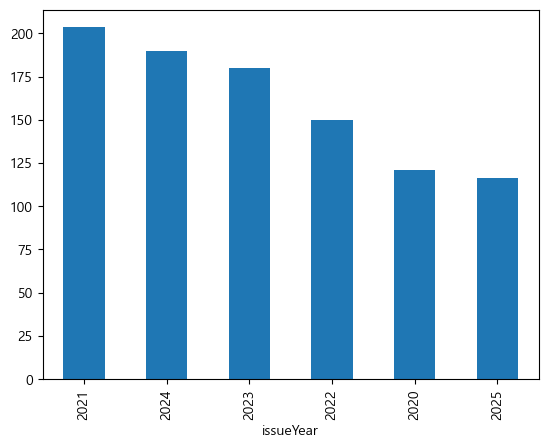

In [37]:
df.groupby('issueYear')['issueVal'].mean().sort_values(ascending=False).plot(kind='bar')

In [38]:
year_trend = df.groupby('issueYear')['issueVal'].mean().reset_index()
year_trend

,issueYear,issueVal
0,2020,121.1
1,2021,203.5
2,2022,150.1
3,2023,180.1
4,2024,190.0
5,2025,116.0


<Axes: xlabel='issueYear', ylabel='issueVal'>

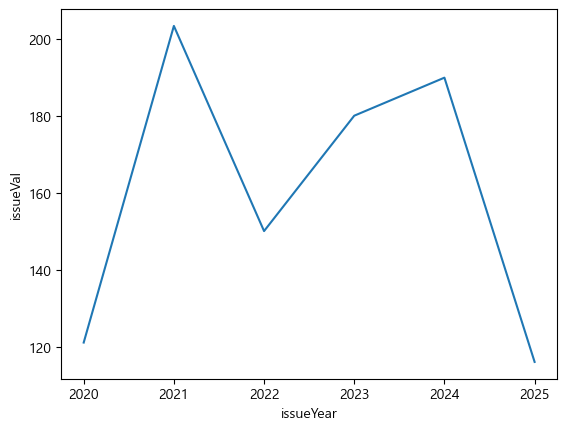

In [39]:
sns.lineplot(data= year_trend,   x='issueYear', y='issueVal'  )

<Axes: xlabel='issueYear', ylabel='issueVal'>

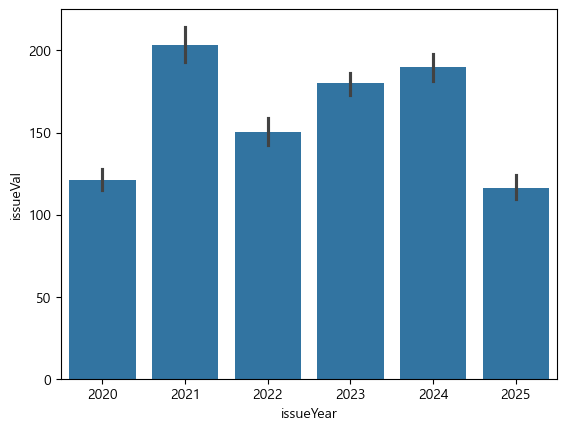

In [40]:
sns.barplot(data=df, x='issueYear', y='issueVal' )

문제: PM10 vs PM25 발령농도 비교

<Axes: xlabel='itemCode', ylabel='issueVal'>

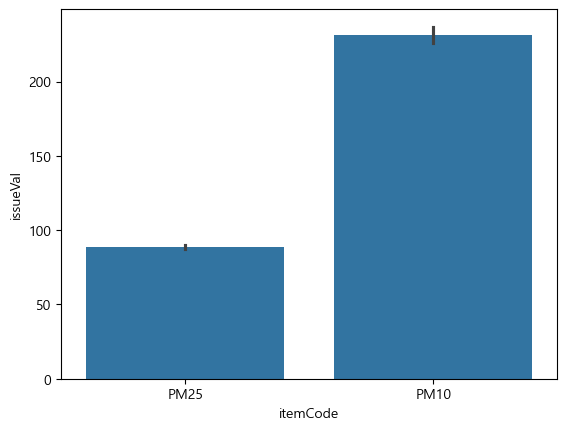

In [41]:
sns.barplot(data=df, x='itemCode',   y='issueVal')

In [42]:
df.groupby('itemCode')['issueVal'].mean()

itemCode
PM10   231.3
PM25    88.7
Name: issueVal, dtype: float64

<Axes: xlabel='itemCode', ylabel='issueVal'>

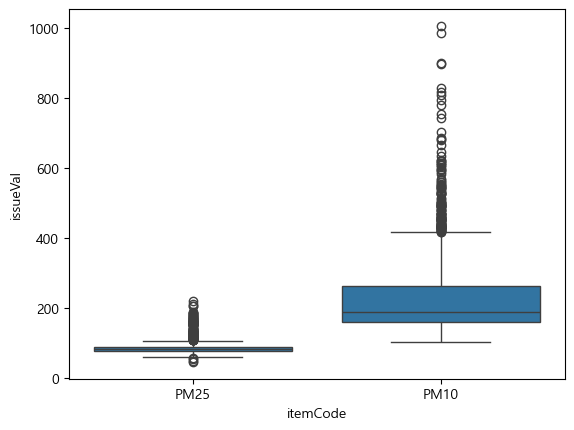

In [43]:
sns.boxplot(data=df,  x='itemCode', y='issueVal')

In [45]:
df.groupby('itemCode')['issueVal'].median()

itemCode
PM10   189.0
PM25    82.0
Name: issueVal, dtype: float64

문제: 발령과 해제 농도

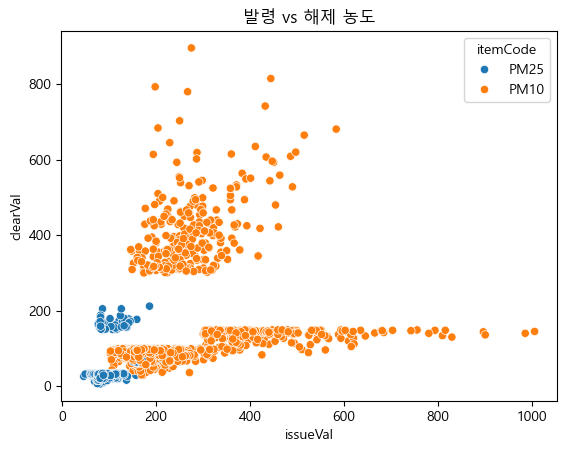

In [46]:
sns.scatterplot(data=df, x='issueVal', y='clearVal', hue ='itemCode')
plt.title('발령 vs 해제 농도')
plt.show()

<Axes: xlabel='districtName', ylabel='issueVal'>

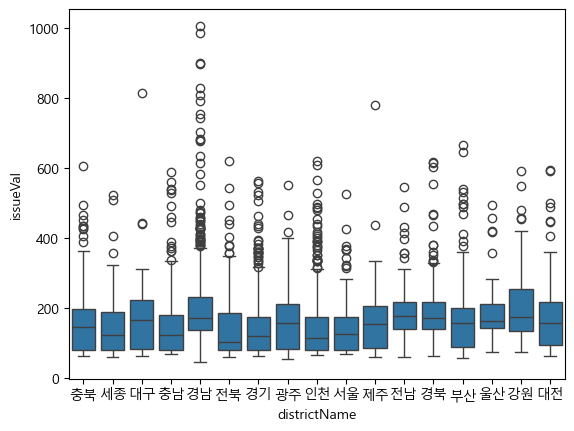

In [47]:
sns.boxplot(data=df, x='districtName', y='issueVal')

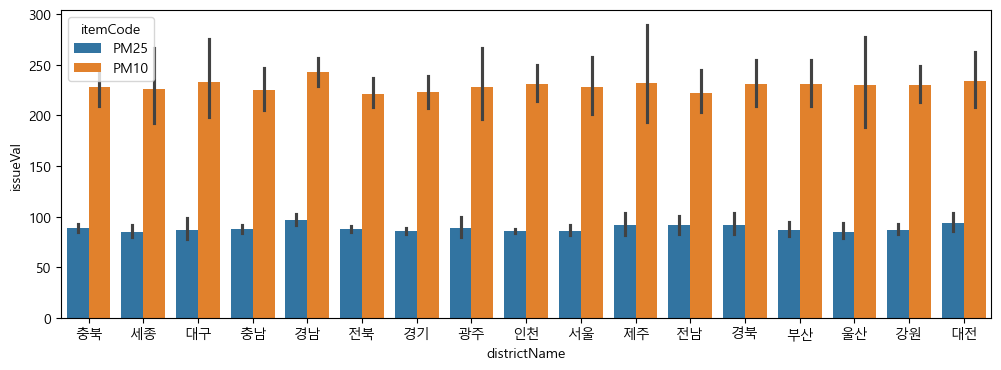

In [48]:
plt.figure(figsize=(12,4))
sns.barplot(data=df, x='districtName', y='issueVal', hue='itemCode')
plt.show()